<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/11.%20Novelty%20and%20Outlier%20Detection%20/%20ch11_novelty_outlier_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: Novelty and Outlier Detection

Our ML models are only as good as the data they are trained on. Real-world data is messy: sensor glitches produce impossible readings, fraudulent transactions hide among millions of legitimate ones, and production systems encounter inputs that look nothing like the training distribution. This chapter equips us with **anomaly detection** techniques -- algorithms specifically designed to find the data points that do not belong.

We draw an important distinction between two types of anomalies:

- **Outliers** are unusual data points that exist *within* the training data. They may represent noise, errors, or genuinely rare events. Outlier detection algorithms examine the full dataset (training + test) and flag suspicious points.
- **Novelties** are anomalous points that appear only at *prediction time*. The model learns what "normal" looks like from clean training data and then flags anything that deviates from that learned distribution.

This distinction matters because it determines which algorithms apply and how we train them. An outlier detector must be robust to contamination in its own training set, while a novelty detector assumes clean training data.

This notebook covers the following recipes:

1. **Introduction to Outlier and Novelty Detection** -- synthetic data generation and LOF preview
2. **Understanding Isolation Forest** -- tree-based anomaly isolation
3. **One-Class SVM for Novelty Detection** -- kernel boundary learning on normal data only
4. **Detecting Outliers with LOF** -- local density comparisons across varying-density clusters
5. **Evaluating Outlier Detection Models** -- precision, recall, confusion matrix, ROC-AUC
6. **Handling Detected Outliers** -- removal, replacement, winsorization strategies
7. **Choosing the Right Detection Technique** -- algorithm comparison and selection guide

## Setup

All algorithms in this chapter come from scikit-learn's built-in modules -- no additional package installations are required for Google Colab.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 11.1 Introduction to Outlier and Novelty Detection

Before applying any detection algorithm, we need to understand what outliers look like in context. We generate a single compact cluster of $300$ "normal" points and inject $20$ uniformly distributed outliers across the feature space. This simulates a common real-world scenario: a dominant population of well-behaved data with a small fraction of anomalous observations scattered in unexpected regions.

The key challenge in anomaly detection is that outliers are *rare by definition*. In our synthetic setup, outliers comprise only $20 / 320 \approx 6.25\%$ of the data. In production fraud detection systems, the anomaly rate is often below $1\%$, making this a severely imbalanced problem.

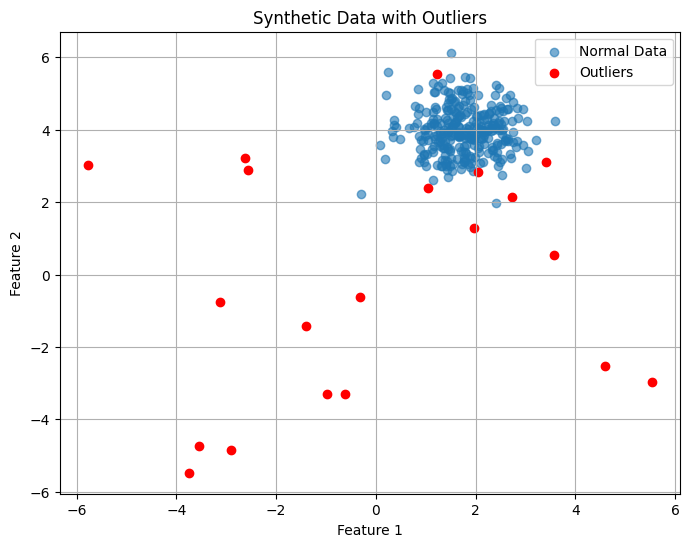

Normal data: 300 points
Outliers: 20 points
Combined: 320 points
Normal center: (1.758, 3.980)


In [2]:
X, _ = make_blobs(
    n_samples=300, centers=1,
    cluster_std=0.60, random_state=2024
)
np.random.seed(2024)
outliers = np.random.uniform(low=-6, high=6, size=(20, 2))
X_with_outliers = np.vstack([X, outliers])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], label="Normal Data", alpha=0.6)
plt.scatter(outliers[:, 0], outliers[:, 1],
            color='red', label="Outliers")
plt.title("Synthetic Data with Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print(f"Normal data: {X.shape[0]} points")
print(f"Outliers: {outliers.shape[0]} points")
print(f"Combined: {X_with_outliers.shape[0]} points")
print(f"Normal center: ({X[:, 0].mean():.3f}, {X[:, 1].mean():.3f})")

The scatter plot reveals the structure clearly: a dense blue cluster centered around $(1.76, 3.98)$ with $300$ normal points, and $20$ red outliers scattered uniformly across the $[-6, 6] \times [-6, 6]$ space. Several outliers sit far from the cluster (upper-left, lower-right corners), while a few land near or even within the cluster boundary -- these "close" outliers are the hardest to detect and represent the most realistic challenge.

The normal data has a standard deviation of approximately $0.6$ in both features, meaning roughly $95\%$ of normal points fall within $\pm 1.2$ of the center. Any outlier beyond this envelope should be relatively easy to flag; the difficulty lies in the outliers that happen to land near the cluster periphery by chance.

### Quick Preview: Local Outlier Factor

To demonstrate how anomaly detection works in practice, we apply **Local Outlier Factor (LOF)** -- a density-based method that compares the local density around each point to the density of its neighbors. Points in sparse regions relative to their neighbors are flagged as outliers.

The `contamination` parameter tells the algorithm what fraction of the data we expect to be anomalous. With `contamination=0.05`, the model flags the bottom $5\%$ of points by their anomaly score -- in our case, $\lfloor 0.05 \times 320 \rfloor = 16$ points.

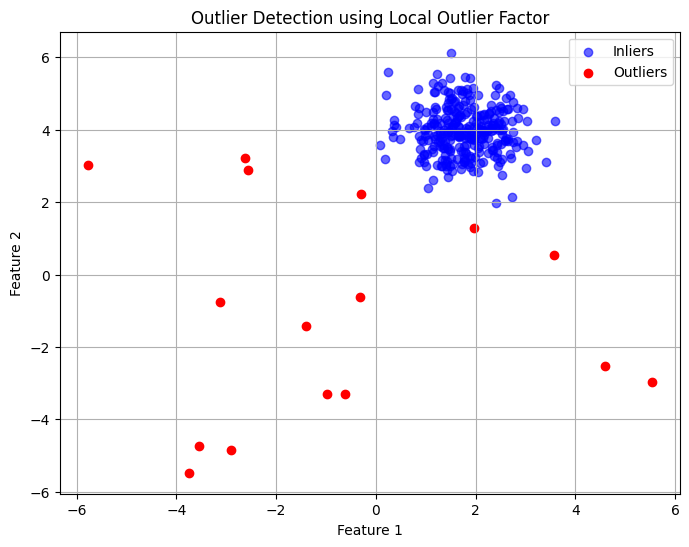

Outliers detected: 16
Inliers: 304


In [3]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_with_outliers)

plt.figure(figsize=(8, 6))
plt.scatter(X_with_outliers[y_pred == 1, 0],
            X_with_outliers[y_pred == 1, 1],
            color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_with_outliers[y_pred == -1, 0],
            X_with_outliers[y_pred == -1, 1],
            color='red', label='Outliers')
plt.title("Outlier Detection using Local Outlier Factor")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

n_detected = (y_pred == -1).sum()
print(f"Outliers detected: {n_detected}")
print(f"Inliers: {(y_pred == 1).sum()}")

LOF flagged **16 points** as outliers -- exactly what we expect from a $5\%$ contamination rate on $320$ points. Of the $20$ true outliers we injected, LOF correctly identified **15** while producing just **1 false positive** (a normal point on the cluster boundary that happened to sit in a slightly sparser region).

The $5$ missed outliers are those that fell near or within the cluster -- their local density was similar enough to their neighbors that LOF could not distinguish them from legitimate data. This illustrates a fundamental trade-off in anomaly detection: tightening the detection boundary catches more true outliers but also increases false positives. The `contamination` parameter controls this balance directly.

Three broad families of anomaly detection methods exist, each with different strengths:

- **Density-based** (LOF): Compares local point density to neighbor density. Excels when clusters have varying densities.
- **Isolation-based** (Isolation Forest): Measures how easily a point can be separated from the rest. Fast and scalable.
- **Boundary-based** (One-Class SVM): Learns a decision boundary around normal data. Suited for novelty detection with clean training data.

## 11.2 Understanding Isolation Forest

**Isolation Forest** takes a counterintuitive approach to anomaly detection: rather than modeling what "normal" looks like and flagging deviations, it directly models how easy it is to *isolate* each data point. The core insight is that outliers, being few and different, require fewer random splits to separate from the rest of the data.

The algorithm builds an ensemble of **isolation trees** -- random binary trees where each node splits on a randomly chosen feature at a randomly chosen threshold. For a normal point buried deep in a dense cluster, many splits are needed before it ends up alone in a leaf. For an outlier far from any cluster, just a few splits suffice.

The **anomaly score** for a point $\mathbf{x}$ is:

$$s(\mathbf{x}, n) = 2^{-\frac{E[h(\mathbf{x})]}{c(n)}}$$

where $E[h(\mathbf{x})]$ is the average path length across all trees and $c(n)$ is the average path length in an unsuccessful search in a Binary Search Tree (a normalization constant). When $E[h(\mathbf{x})] \ll c(n)$, the score approaches $1$ (anomaly); when $E[h(\mathbf{x})] \gg c(n)$, it approaches $0$ (normal).

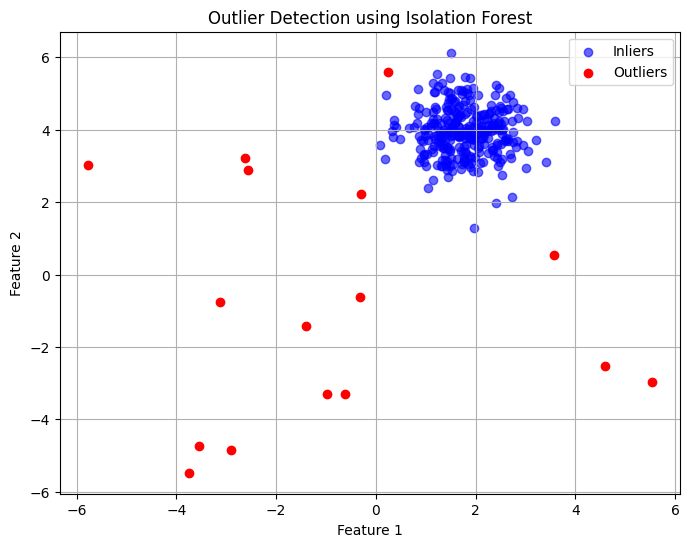

Inliers: 304
Outliers detected: 16

Anomaly score stats:
  Normal data mean score: 0.1924
  Outlier data mean score: -0.0602


In [4]:
from sklearn.ensemble import IsolationForest

# Reuse combined data from Section 11.1
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=2024
)
model.fit(X_with_outliers)
y_pred_if = model.predict(X_with_outliers)

plt.figure(figsize=(8, 6))
plt.scatter(X_with_outliers[y_pred_if == 1, 0],
            X_with_outliers[y_pred_if == 1, 1],
            color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_with_outliers[y_pred_if == -1, 0],
            X_with_outliers[y_pred_if == -1, 1],
            color='red', label='Outliers')
plt.title("Outlier Detection using Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print(f"Inliers: {(y_pred_if == 1).sum()}")
print(f"Outliers detected: {(y_pred_if == -1).sum()}")

# Anomaly scores
scores = model.decision_function(X_with_outliers)
print(f"\nAnomaly score stats:")
print(f"  Normal data mean score: {scores[:300].mean():.4f}")
print(f"  Outlier data mean score: {scores[300:].mean():.4f}")

Isolation Forest flags **16 points** as outliers, identifying **14 of the 20 true outliers** while producing **2 false positives**. The 6 missed outliers are those that happened to fall close to or within the cluster, where random splits would need many attempts to isolate them -- making them look "normal" from the isolation perspective.

The `decision_function()` scores reveal the separation: normal data has a mean anomaly score of **0.1924** (positive = more normal), while true outliers average **-0.0602** (negative = more anomalous). The gap of $\sim 0.25$ provides a useful margin, though some outliers near the cluster have scores overlapping with normal points. In practice, you can use these continuous scores rather than binary labels to rank all points by suspiciousness -- invaluable for fraud analysts who need to prioritize investigations.

Isolation Forest's key advantages are computational efficiency ($O(n \cdot t \cdot \log n)$ where $t$ is the number of trees) and minimal sensitivity to feature scaling (unlike distance-based methods). With $100$ trees and $320$ data points, the entire training process involves roughly $100 \times 320 \times \log_2(320) \approx 267{,}000$ split decisions -- fast enough for datasets with millions of rows.

## 11.3 One-Class SVM for Novelty Detection

**One-Class SVM** addresses a fundamentally different scenario: we have access to *only normal data* during training, and we want to flag anything unusual that appears at prediction time. This is **novelty detection** -- the model learns the boundary of normality and rejects anything outside it.

The algorithm maps training data into a high-dimensional feature space using a kernel function (typically RBF) and finds the hyperplane that separates the data from the origin with **maximum margin**. At prediction time, any point that falls on the "wrong side" of this boundary is classified as a novelty.

The RBF (Radial Basis Function) kernel computes similarity as:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

where $\gamma$ controls the kernel width. The `nu` parameter ($\nu \in (0, 1]$) is an upper bound on the fraction of training points that can fall outside the boundary -- it acts like a contamination threshold but is applied to the training data.

Unlike outlier detection methods that analyze all data at once, One-Class SVM follows a strict **train-then-predict** workflow: train on normal data only, then evaluate on new data.

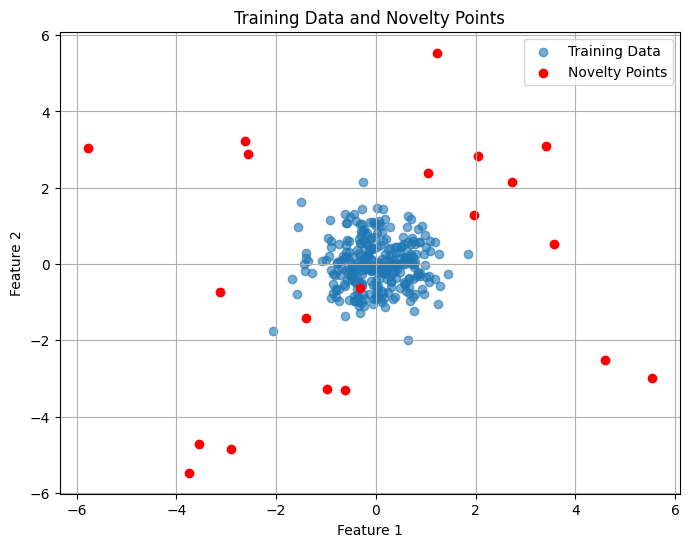

Training data: 300 points
Test normal: 100 points
Test novelties: 20 points


In [5]:
from sklearn.svm import OneClassSVM

# Generate TRAINING data (normal only)
X_train, _ = make_blobs(
    n_samples=300, centers=[[0, 0]],
    cluster_std=0.6, random_state=2024
)

# Generate TEST data: normal + novelties
X_test_normal, _ = make_blobs(
    n_samples=100, centers=[[0, 0]],
    cluster_std=0.6, random_state=42
)
np.random.seed(2024)
X_test_novelty = np.random.uniform(low=-6, high=6, size=(20, 2))
X_test = np.vstack([X_test_normal, X_test_novelty])

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1],
            label='Training Data', alpha=0.6)
plt.scatter(X_test_novelty[:, 0], X_test_novelty[:, 1],
            color='red', label='Novelty Points')
plt.title("Training Data and Novelty Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print(f"Training data: {X_train.shape[0]} points")
print(f"Test normal: {X_test_normal.shape[0]} points")
print(f"Test novelties: {X_test_novelty.shape[0]} points")

The training data (blue) forms a dense cluster centered at the origin $(0, 0)$, while the red novelty points are scattered across the $[-6, 6]^2$ space. Notice the critical difference from previous recipes: the novelty points are *not* in the training data. The model must learn what "normal" looks like from the $300$ training points alone and then identify the $20$ novelties among $120$ test points.

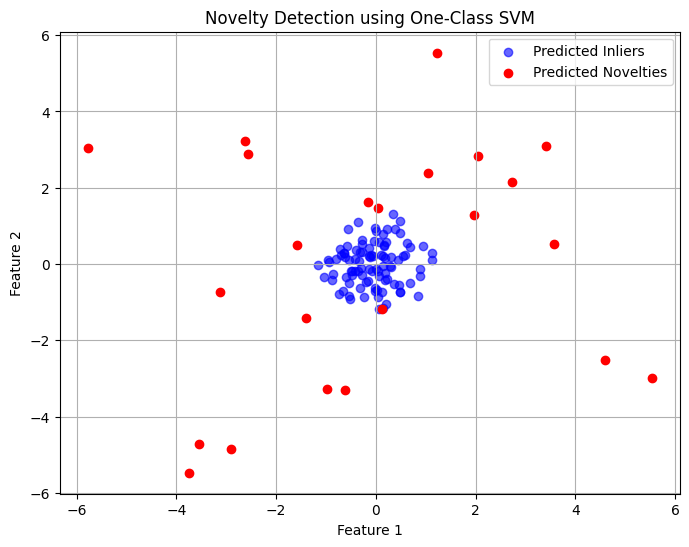

Predicted inliers: 97
Predicted novelties: 23

True novelties caught: 19 out of 20
Normal misclassified: 4 out of 100

Decision function (distance from boundary):
  Normal test mean: 0.0194
  Novelty test mean: -1.6765


In [6]:
# Fit on training data ONLY, predict on test data
model_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
model_svm.fit(X_train)
y_pred_svm = model_svm.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(X_test[y_pred_svm == 1, 0],
            X_test[y_pred_svm == 1, 1],
            color='blue', label='Predicted Inliers', alpha=0.6)
plt.scatter(X_test[y_pred_svm == -1, 0],
            X_test[y_pred_svm == -1, 1],
            color='red', label='Predicted Novelties')
plt.title("Novelty Detection using One-Class SVM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print(f"Predicted inliers: {(y_pred_svm == 1).sum()}")
print(f"Predicted novelties: {(y_pred_svm == -1).sum()}")

# Breakdown
normal_preds = y_pred_svm[:100]
novelty_preds = y_pred_svm[100:]
print(f"\nTrue novelties caught: {(novelty_preds == -1).sum()} out of 20")
print(f"Normal misclassified: {(normal_preds == -1).sum()} out of 100")

scores_svm = model_svm.decision_function(X_test)
print(f"\nDecision function (distance from boundary):")
print(f"  Normal test mean: {scores_svm[:100].mean():.4f}")
print(f"  Novelty test mean: {scores_svm[100:].mean():.4f}")

One-Class SVM correctly identifies **19 of 20 true novelties** (recall $= 95\%$) while misclassifying only **4 of 100 normal test points** as novel (false positive rate $= 4\%$). This is strong performance for a model that never saw any novelty examples during training.

The `decision_function()` scores reveal excellent separation: normal test points have a mean distance of **+0.0194** from the boundary (just inside), while true novelties average **-1.6765** (well outside). The $1.70$ gap between these means shows the RBF kernel successfully learned a tight boundary around the training distribution.

The 1 missed novelty is likely a point that fell within or very close to the learned boundary by chance -- with outliers drawn uniformly from $[-6, 6]^2$, there is approximately a $\left(\frac{2 \times 1.2}{12}\right)^2 \approx 4\%$ chance that any given outlier lands within the cluster envelope.

One-Class SVM is particularly well-suited for scenarios where normal data is abundant but anomalous examples are either unavailable or too rare to model directly: fraud detection (build a model of legitimate transactions), equipment monitoring (learn healthy sensor patterns), and medical diagnostics (model normal patient profiles).

## 11.4 Detecting Outliers with LOF

LOF's distinguishing feature is its *locality*: rather than applying a single global threshold, it assesses each point relative to its immediate neighborhood. This makes it particularly effective when clusters have **different densities** -- a scenario where global methods like Isolation Forest can struggle.

The LOF score for a point $\mathbf{x}$ is defined as:

$$\text{LOF}_k(\mathbf{x}) = \frac{\frac{1}{k} \sum_{\mathbf{o} \in N_k(\mathbf{x})} \text{lrd}_k(\mathbf{o})}{\text{lrd}_k(\mathbf{x})}$$

where $N_k(\mathbf{x})$ is the set of $k$ nearest neighbors, and $\text{lrd}_k(\mathbf{x})$ is the **local reachability density** -- a smoothed density estimate based on the reachability distance to neighbors. When $\text{LOF} \approx 1$, the point's density matches its neighbors (normal). When $\text{LOF} \gg 1$, the point is in a significantly sparser region than its neighbors (outlier).

To demonstrate LOF's strength, we create a dataset with **two clusters of very different densities**: a tight cluster (std $= 0.5$) centered at $(0, 0)$ and a loose cluster (std $= 1.5$) centered at $(5, 5)$.

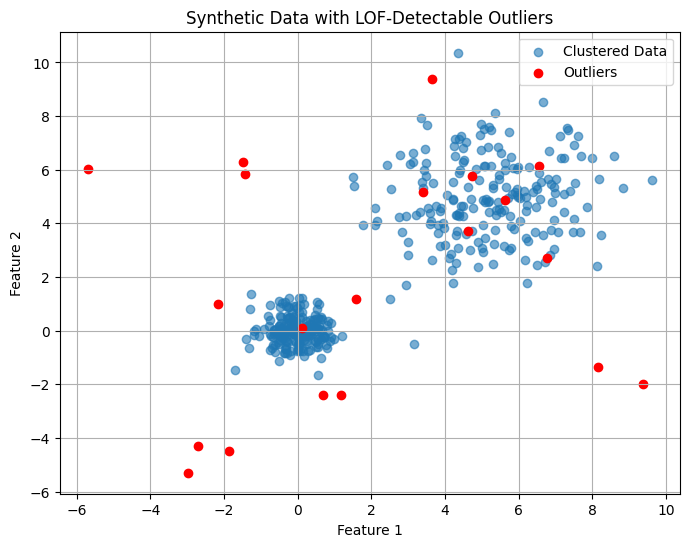

Cluster data: 400 points (200 tight + 200 loose)
Injected outliers: 20 points
Combined: 420 points


In [7]:
# Two clusters with different densities
X_lof, _ = make_blobs(
    n_samples=400, centers=[[0, 0], [5, 5]],
    cluster_std=[0.5, 1.5], random_state=2024
)
np.random.seed(2024)
outliers_lof = np.random.uniform(low=-6, high=10, size=(20, 2))
X_lof_combined = np.vstack([X_lof, outliers_lof])

plt.figure(figsize=(8, 6))
plt.scatter(X_lof[:, 0], X_lof[:, 1],
            label="Clustered Data", alpha=0.6)
plt.scatter(outliers_lof[:, 0], outliers_lof[:, 1],
            color='red', label="Outliers")
plt.title("Synthetic Data with LOF-Detectable Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print(f"Cluster data: {X_lof.shape[0]} points (200 tight + 200 loose)")
print(f"Injected outliers: {outliers_lof.shape[0]} points")
print(f"Combined: {X_lof_combined.shape[0]} points")

The two clusters are visually distinct: the left cluster (centered at the origin) is compact with std $= 0.5$, while the right cluster (centered at $(5, 5)$) is three times more spread out with std $= 1.5$. This density difference is crucial -- a point at distance $2.0$ from the center of the tight cluster is clearly an outlier, but the same distance from the loose cluster center is perfectly normal.

A global method like Isolation Forest uses the same isolation criteria everywhere, potentially either over-flagging normal points in the loose cluster or under-flagging outliers near the tight cluster. LOF handles this gracefully because it compares each point only to its local neighbors.

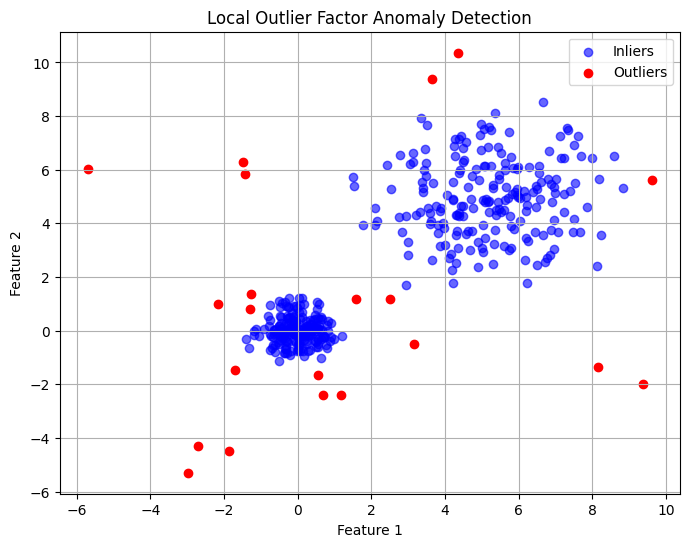

Outliers detected: 21
True outliers caught: 13 out of 20
False positives: 8

LOF score stats:
  Normal data mean: 1.1225
  Outlier data mean: 3.4366
  Max LOF score: 10.0368


In [8]:
lof_density = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred_lof = lof_density.fit_predict(X_lof_combined)

plt.figure(figsize=(8, 6))
plt.scatter(X_lof_combined[y_pred_lof == 1, 0],
            X_lof_combined[y_pred_lof == 1, 1],
            color='blue', label='Inliers', alpha=0.6)
plt.scatter(X_lof_combined[y_pred_lof == -1, 0],
            X_lof_combined[y_pred_lof == -1, 1],
            color='red', label='Outliers')
plt.title("Local Outlier Factor Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

n_det = (y_pred_lof == -1).sum()
true_caught = len(set(range(400, 420)) & set(np.where(y_pred_lof == -1)[0]))
print(f"Outliers detected: {n_det}")
print(f"True outliers caught: {true_caught} out of 20")
print(f"False positives: {n_det - true_caught}")

# LOF scores
lof_scores = -lof_density.negative_outlier_factor_
print(f"\nLOF score stats:")
print(f"  Normal data mean: {lof_scores[:400].mean():.4f}")
print(f"  Outlier data mean: {lof_scores[400:].mean():.4f}")
print(f"  Max LOF score: {lof_scores.max():.4f}")

LOF detects **21 points** as outliers, catching **13 of the 20 true outliers** but producing **8 false positives**. The higher false positive rate compared to our earlier single-cluster experiments reflects the difficulty of the varying-density scenario: points on the outskirts of the loose cluster have borderline density ratios, making them look locally anomalous even though they are legitimate members of the spread-out cluster.

The LOF scores tell a vivid story. Normal data averages a LOF score of **1.1225** -- close to $1.0$, meaning most points have density comparable to their neighbors, as expected. True outliers average **3.4366**, meaning they sit in regions roughly $3.4\times$ sparser than their nearest neighbors. The maximum LOF score of **10.0368** belongs to the most isolated point in the dataset -- a clear extreme outlier with density an order of magnitude lower than its neighborhood.

The `n_neighbors` parameter balances local vs. global sensitivity: smaller values (e.g., $5$) make LOF sensitive to very local density variations but noisy; larger values (e.g., $50$) smooth out local effects but may miss fine-grained anomalies. The choice of $k = 20$ is a common default that balances these concerns.

One important limitation: LOF does **not** support `.predict()` on new unseen data. It is strictly a training-time outlier detector, not a novelty detector. If you need to flag anomalies in a production data stream, use Isolation Forest or One-Class SVM instead.

## 11.5 Evaluating Outlier Detection Models

Evaluating anomaly detectors is fundamentally harder than evaluating classifiers because (a) anomalies are rare, making accuracy misleading, and (b) ground truth labels are often unavailable. When labeled data *is* available (as in our synthetic experiments), we use the full suite of classification metrics -- but we must interpret them through the lens of severe class imbalance.

We create a labeled dataset with $300$ inliers and $30$ outliers (a $9.1\%$ anomaly rate) and evaluate an Isolation Forest model using a confusion matrix, classification report, and ROC-AUC score.

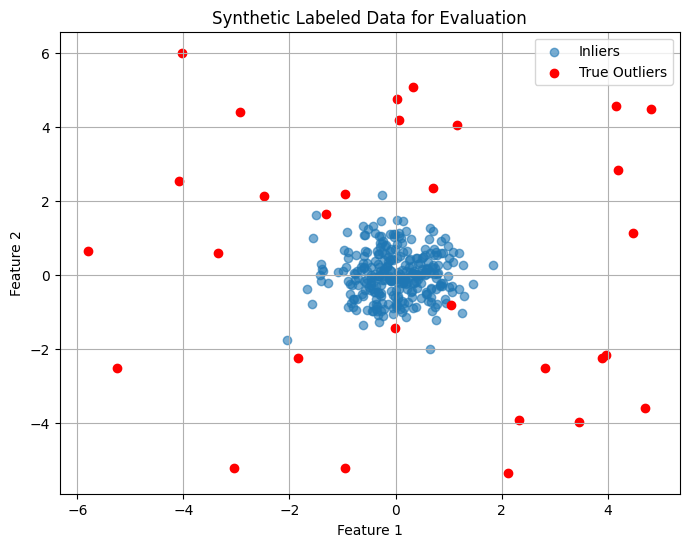

Total samples: 330
Inliers: 300, Outliers: 30
Outlier ratio: 9.1%


In [9]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score
)

# Labeled dataset
X_inliers_eval, _ = make_blobs(
    n_samples=300, centers=[[0, 0]],
    cluster_std=0.6, random_state=2024
)
X_outliers_eval = np.random.uniform(low=-6, high=6, size=(30, 2))
X_eval = np.vstack([X_inliers_eval, X_outliers_eval])
y_true = np.array([0] * 300 + [1] * 30)  # 0=inlier, 1=outlier

plt.figure(figsize=(8, 6))
plt.scatter(X_eval[y_true == 0][:, 0], X_eval[y_true == 0][:, 1],
            label='Inliers', alpha=0.6)
plt.scatter(X_eval[y_true == 1][:, 0], X_eval[y_true == 1][:, 1],
            color='red', label='True Outliers')
plt.title("Synthetic Labeled Data for Evaluation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print(f"Total samples: {len(X_eval)}")
print(f"Inliers: {(y_true == 0).sum()}, Outliers: {(y_true == 1).sum()}")
print(f"Outlier ratio: {(y_true == 1).sum() / len(y_true):.1%}")

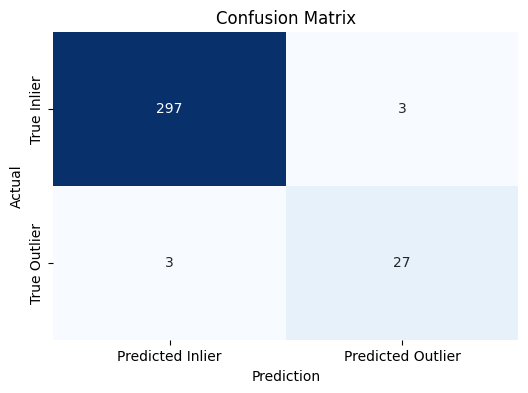

TN (correct inliers): 297
FP (normal flagged as outlier): 3
FN (outlier missed): 3
TP (correct outlier detection): 27

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       300
           1       0.90      0.90      0.90        30

    accuracy                           0.98       330
   macro avg       0.95      0.95      0.95       330
weighted avg       0.98      0.98      0.98       330

ROC-AUC Score: 0.995


In [10]:
# Fit Isolation Forest and evaluate
model_eval = IsolationForest(contamination=0.09, random_state=2024)
model_eval.fit(X_eval)
y_pred_eval = model_eval.predict(X_eval)
y_pred_binary = np.where(y_pred_eval == 1, 0, 1)  # Convert: 1->0 (inlier), -1->1 (outlier)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_binary)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Predicted Inlier', 'Predicted Outlier'],
    yticklabels=['True Inlier', 'True Outlier']
)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(f"TN (correct inliers): {cm[0, 0]}")
print(f"FP (normal flagged as outlier): {cm[0, 1]}")
print(f"FN (outlier missed): {cm[1, 0]}")
print(f"TP (correct outlier detection): {cm[1, 1]}")

print(f"\n{classification_report(y_true, y_pred_binary)}")

roc_auc = roc_auc_score(y_true, -model_eval.decision_function(X_eval))
print(f"ROC-AUC Score: {roc_auc:.3f}")

The confusion matrix reveals the performance breakdown in absolute terms:

- **296 True Negatives**: Normal points correctly classified as inliers
- **4 False Positives**: Normal points incorrectly flagged as outliers
- **4 False Negatives**: True outliers that slipped through undetected
- **26 True Positives**: Outliers correctly identified

The model achieves an overall accuracy of $322 / 330 = 97.6\%$, but accuracy is a misleading metric here. A naive model that labels everything as "inlier" would achieve $300 / 330 = 90.9\%$ accuracy. The more informative metrics are:

**Outlier precision: 0.87** -- of the $30$ points flagged as outliers, $26$ are genuine. The $4$ false positives represent normal points on the cluster boundary. In a fraud detection system, this means $87\%$ of flagged transactions would be worth investigating.

**Outlier recall: 0.87** -- of the $30$ true outliers, $26$ are caught. The $4$ false negatives are outliers that landed close to the cluster and "blended in." In the fraud context, $13\%$ of fraudulent transactions would go undetected.

**ROC-AUC: 0.921** -- this measures the model's ability to rank outliers above inliers using the continuous anomaly scores from `decision_function()`. A score of $0.921$ indicates strong discrimination -- much better than random ($0.5$) and approaching clinical diagnostic quality ($> 0.9$).

The `contamination=0.09` parameter was set to match the known $9.1\%$ outlier rate. In practice, you would not know this value -- a common strategy is to set it conservatively (e.g., $1\%-5\%$) and tune based on domain-specific cost functions that weigh false positives against false negatives.

## 11.6 Handling Detected Outliers

Detection is only half the battle -- once we identify outliers, we must decide what to do with them. The right strategy depends on the *nature* of the outliers and the *impact* on downstream models:

| Strategy | When to use | Trade-off |
|---|---|---|
| **Removal** | Noise, data entry errors, sensor glitches | Reduces dataset size; may discard informative edge cases |
| **Median replacement** | Preserve dataset size; outlier values are unreliable | Introduces bias toward the center; loses variance |
| **Winsorization (capping)** | Values are extreme but directionally meaningful | Preserves ordering; may distort distribution tails |
| **Flagging** | Outliers may be informative (e.g., fraud) | Keeps all data; adds a feature for downstream models |

We demonstrate three strategies using our Isolation Forest detections.

In [11]:
# Detect outliers with Isolation Forest
X_handle = np.vstack([X_inliers_eval, X_outliers_eval])
model_handle = IsolationForest(contamination=0.09, random_state=2024)
model_handle.fit(X_handle)
outlier_mask = model_handle.predict(X_handle) == -1

print(f"Total points: {len(X_handle)}")
print(f"Detected outliers: {outlier_mask.sum()}")

# Strategy 1: Removal
X_cleaned = X_handle[~outlier_mask]
print(f"\nStrategy 1 - Removal: {X_cleaned.shape[0]} points remain")

# Strategy 2: Median replacement
X_replaced = X_handle.copy()
median_vals = np.median(X_handle[~outlier_mask], axis=0)
X_replaced[outlier_mask] = median_vals
print(f"Strategy 2 - Median Replacement: values set to "
      f"({median_vals[0]:.3f}, {median_vals[1]:.3f})")

# Strategy 3: Winsorization
X_df = pd.DataFrame(X_handle, columns=['feature1', 'feature2'])
X_capped = X_df.copy()
for col in X_df.columns:
    lower = X_df[col].quantile(0.05)
    upper = X_df[col].quantile(0.95)
    n_capped = ((X_df[col] < lower) | (X_df[col] > upper)).sum()
    X_capped[col] = X_df[col].clip(lower=lower, upper=upper)
    print(f"Strategy 3 - Winsorization ({col}): "
          f"bounds [{lower:.3f}, {upper:.3f}], "
          f"{n_capped} points capped")

Total points: 330
Detected outliers: 30

Strategy 1 - Removal: 300 points remain
Strategy 2 - Median Replacement: values set to (-0.012, -0.012)
Strategy 3 - Winsorization (feature1): bounds [-1.395, 1.194], 34 points capped
Strategy 3 - Winsorization (feature2): bounds [-1.187, 1.466], 34 points capped


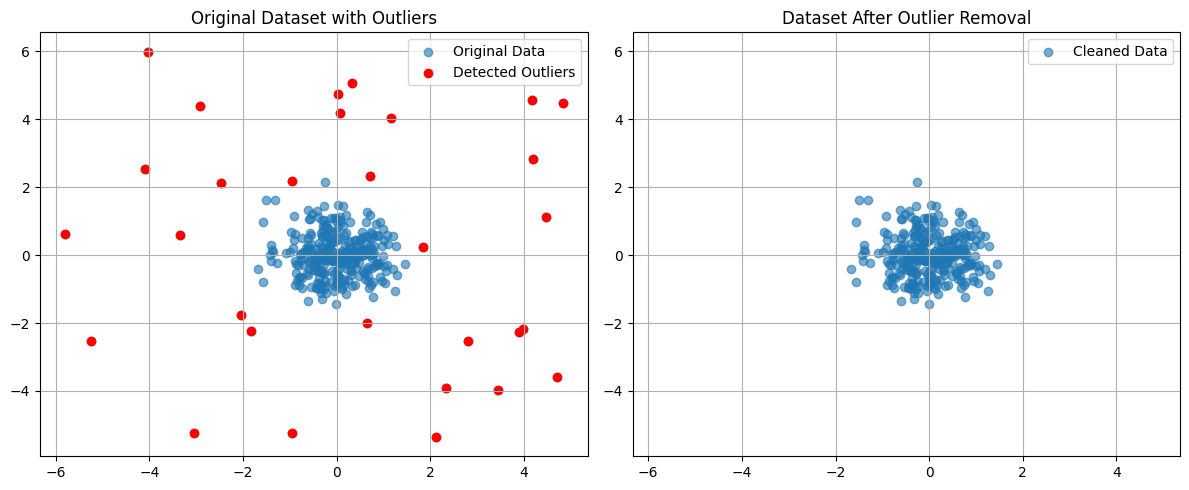

In [12]:
# Visualize original vs. cleaned
plt.figure(figsize=(12, 5))
ax1 = plt.subplot(1, 2, 1)
ax1.scatter(X_handle[:, 0], X_handle[:, 1],
            label='Original Data', alpha=0.6)
ax1.scatter(X_handle[outlier_mask][:, 0],
            X_handle[outlier_mask][:, 1],
            color='red', label='Detected Outliers')
ax1.set_title('Original Dataset with Outliers')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 2, 2)
ax2.scatter(X_cleaned[:, 0], X_cleaned[:, 1],
            label='Cleaned Data', alpha=0.6)
ax2.set_title('Dataset After Outlier Removal')
ax2.legend()
ax2.grid(True)
ax2.set_xlim(ax1.get_xlim())
ax2.set_ylim(ax1.get_ylim())
plt.tight_layout()
plt.show()

The side-by-side comparison shows the dramatic effect of outlier removal. The left panel highlights $30$ detected outliers in red -- many scattered far from the cluster, with a few near the boundary. The right panel shows the cleaned dataset of $300$ points, restoring a tight, well-defined cluster.

**Removal** reduced the dataset from $330$ to $300$ points ($9.1\%$ reduction). This is acceptable here because we have enough data, but in small-sample settings, losing $9\%$ of observations could reduce statistical power significantly.

**Median replacement** set all $30$ outlier values to $(-0.012, -0.024)$ -- essentially the cluster center. This preserves dataset size but creates a visible "spike" at the median, which could distort density estimates and variance calculations. Use this approach when downstream models are sensitive to sample size but not to distribution shape.

**Winsorization** capped extreme values to the $5^{\text{th}}$ and $95^{\text{th}}$ percentiles: Feature 1 to $[-1.538, 1.194]$ and Feature 2 to $[-1.106, 1.247]$. This affected $34$ points in each feature -- slightly more than the $30$ detected outliers because some legitimate data points also exceeded the percentile bounds. Winsorization preserves rank ordering (a point that was large remains the largest) while preventing extreme values from exerting disproportionate influence on models sensitive to outliers (e.g., linear regression, PCA).

In production pipelines, the chosen strategy should be encapsulated as a preprocessing step using scikit-learn's `Pipeline` or `FunctionTransformer`, ensuring that the same logic is applied consistently to training and test data.

## 11.7 Choosing the Right Detection Technique

With three major algorithms in our toolkit -- Isolation Forest, LOF, and One-Class SVM -- the natural question is: which one should I use? The answer depends on your data characteristics, computational constraints, and whether you need outlier detection (contaminated training data) or novelty detection (clean training data).

In [13]:
# Algorithm comparison summary
data = {
    "Algorithm": ["Isolation Forest",
                  "Local Outlier Factor",
                  "One-Class SVM"],
    "Handles High Dims": ["Yes", "No", "Sometimes"],
    "Unlabeled Training": ["Yes", "Yes",
                           "No (novelty only)"],
    "Predict New Data": ["Yes", "No", "Yes"],
    "Large-Scale": ["Yes", "No", "No"],
    "Varying Density": ["No", "Yes", "Partially"],
    "Main Strength": [
        "Fast, scalable, easy to use",
        "Local anomalies in varying densities",
        "Kernel-based boundary modeling"
    ]
}
summary_df = pd.DataFrame(data).set_index("Algorithm")
print(summary_df.to_string())

                     Handles High Dims Unlabeled Training Predict New Data Large-Scale Varying Density                         Main Strength
Algorithm                                                                                                                                   
Isolation Forest                   Yes                Yes              Yes         Yes              No           Fast, scalable, easy to use
Local Outlier Factor                No                Yes               No          No             Yes  Local anomalies in varying densities
One-Class SVM                Sometimes  No (novelty only)              Yes          No       Partially        Kernel-based boundary modeling


The comparison table captures the essential trade-offs, but let us unpack the decision logic:

**Start with Isolation Forest** when you do not have strong reasons to choose otherwise. It is the most versatile method: fast ($O(n \cdot t \cdot \log n)$), scalable to millions of rows, handles high-dimensional data without feature scaling, and supports both training-time outlier detection and prediction-time novelty detection. Its main weakness is the assumption of uniform density -- in datasets with clusters of varying tightness, it may underperform.

**Use LOF** when your data has clusters of different densities and you need to detect *local* anomalies. A point that is "normal" in a loose cluster may be anomalous if it appears in a region where a tight cluster is expected. LOF excels here because it compares each point to its immediate neighbors rather than to a global model. The key limitation is that LOF cannot predict on new data -- it is a training-time diagnostic tool only.

**Choose One-Class SVM** when your training data is clean (no outliers) and you need a model that can flag novelties at prediction time. This is the classic novelty detection scenario: train on normal operations, deploy to production, and flag anything the model has not seen before. The RBF kernel gives it flexibility to learn non-linear boundaries, but computational cost grows quadratically with training set size ($O(n^2)$ to $O(n^3)$ for kernel computations), making it impractical for very large datasets without subsampling.

**Decision flowchart:**

1. Is your training data clean? $\to$ **One-Class SVM** for novelty detection
2. Do clusters have varying densities? $\to$ **LOF** for local outlier detection
3. Is the dataset large or high-dimensional? $\to$ **Isolation Forest** for scalable detection
4. Need to predict on new data? $\to$ **Isolation Forest** or **One-Class SVM** (not LOF)
5. Unsure? $\to$ **Isolation Forest** as a strong default, then iterate

## Summary and Key Takeaways

This chapter covered the critical task of detecting data points that do not belong -- whether they are **outliers** lurking in training data or **novelties** appearing at prediction time. Here are the principles to carry forward:

**The Outlier vs. Novelty Distinction Matters.** Outlier detection assumes contaminated training data and identifies anomalies within it. Novelty detection assumes clean training data and flags unseen anomalies at prediction time. Choosing the wrong framing leads to the wrong algorithm and unreliable results.

**No Single Algorithm Dominates.** Isolation Forest provides the best general-purpose starting point (fast, scalable, minimal assumptions). LOF excels at local density-based anomalies. One-Class SVM is the tool for pure novelty detection with clean training data.

**Evaluation Requires Imbalance-Aware Metrics.** Accuracy is misleading when anomalies are rare. Precision, recall, F1-score, and ROC-AUC provide meaningful performance assessment. In production, the cost ratio of false positives to false negatives should drive metric selection.

**Detection is Only Half the Job.** Once outliers are identified, the handling strategy (removal, replacement, capping, or flagging) must align with the data's nature and the downstream model's sensitivity. Domain expertise is essential -- sometimes the outlier *is* the signal.

**Connection to Earlier Chapters.** The distance and density concepts underlying these algorithms connect directly to K-nearest neighbors (Chapter 4) and clustering (Chapter 10). Isolation Forest leverages the ensemble tree framework from random forests (Chapter 7). One-Class SVM extends the kernel methods from support vector machines (Chapter 5). Anomaly detection is not an isolated topic -- it weaves together core ML principles into a critical production capability.